# Visualización de la Evaluación de Métodos de Extracción
Este notebook consolida los resultados de todos los métodos evaluados y permite comparar visualmente su rendimiento en los archivos de `extract-bench`, diferenciando entre imágenes de la carpeta `images` y texto seleccionable de la carpeta `pdfs`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid")

# Configurar fuente Palatino
plt.rcParams['font.family'] = 'serif'

### 1. Carga de Datos
Iteramos sobre todos los archivos `results.csv` en la carpeta `evaluations_result/` para crear un único DataFrame, diferenciando entre `images` (imágenes) y `pdfs` (texto seleccionable).

In [2]:
eval_dir = Path("evaluations_result")
all_data = []

for doc_type in ["images", "pdfs"]:
    type_dir = eval_dir / doc_type
    if not type_dir.exists():
        continue
    for method_dir in type_dir.iterdir():
        if method_dir.is_dir():
            csv_path = method_dir / "results.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df['Metodo'] = method_dir.name
                df['Tipo Documento'] = doc_type
                all_data.append(df)

if all_data:
    df_full = pd.concat(all_data, ignore_index=True)

    # Mapeo para convertir el nombre de la carpeta al nombre que usamos en la gráfica
    name_mapping = {
        'docling': 'Docling',
        'docling_header': 'Docling + header',
        'mineru': 'MinerU',
        'mineru_header': 'MinerU + header',
        'pymupdf': 'PyMuPDF4LLM',
        'pymupdf_header': 'PyMuPDF4LLM + header',
        'pymupdf_text': 'PyMuPDF',
        'pymupdf_text_header': 'PyMuPDF + header'
    }
    
    # Aplicar el mapeo a la columna Metodo
    df_full['Metodo'] = df_full['Metodo'].map(name_mapping).fillna(df_full['Metodo'])
    # Limpiar errores: Convertir "Error" a NaN y asegurar que la columna es numérica
    df_full['Puntuación'] = pd.to_numeric(df_full['Puntuación'], errors='coerce')
    df_full = df_full.dropna(subset=['Puntuación'])
    print(f"Cargados {len(df_full)} registros de evaluación en total.")
    
    # Separar por tipo de documento
    df_images = df_full[df_full['Tipo Documento'] == 'images'].copy()
    df_pdfs = df_full[df_full['Tipo Documento'] == 'pdfs'].copy()
    
    # Limpiar nombre de archivo: quitar extensión para mostrar solo el stem
    df_images['Archivo'] = df_images['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    df_pdfs['Archivo'] = df_pdfs['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    
    mean_scores_images = df_images.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    mean_scores_pdfs = df_pdfs.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    
    method_colors = {
        'Docling': '#4A90D9',
        'Docling + header': '#2C5F8E',
        'MinerU': '#50B872',
        'MinerU + header': '#2E8B57',
        'PyMuPDF4LLM': '#FF745C',
        'PyMuPDF4LLM + header': '#D11F00',
        'PyMuPDF': '#9B72CF',
        'PyMuPDF + header': '#6B4FA0'
    }
else:
    print("No se encontraron resultados.")
    df_images = pd.DataFrame()
    df_pdfs = pd.DataFrame()

Cargados 785 registros de evaluación en total.


### 2. Imágenes - Puntuación Media por Método

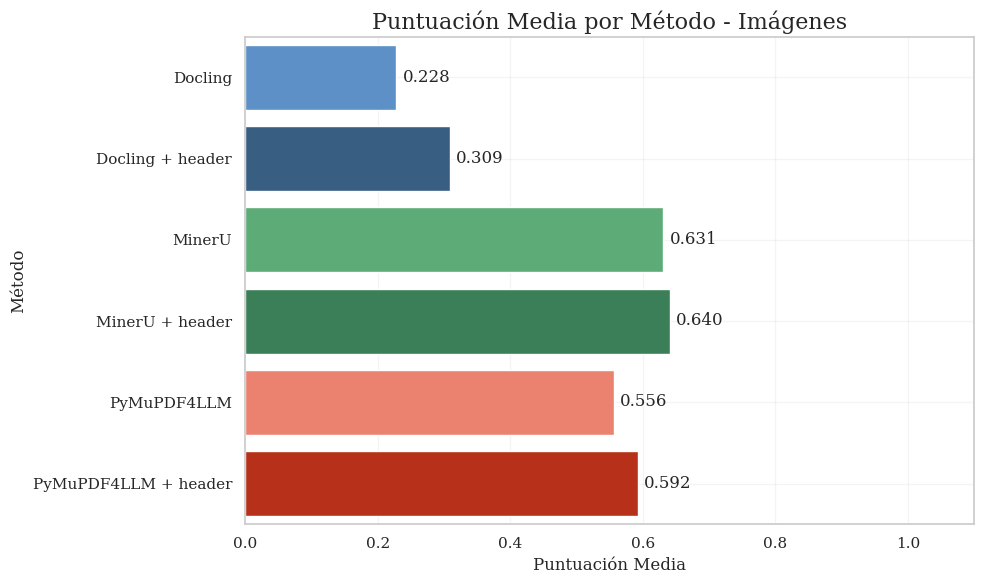

In [3]:
if not df_images.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in mean_scores_images['Metodo'].unique()]
    
    ax = sns.barplot(data=mean_scores_images, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    plt.title('Puntuación Media por Método - Imágenes', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de imágenes para visualizar.")

### 3. Imágenes - Distribución de Puntuaciones (Boxplot)

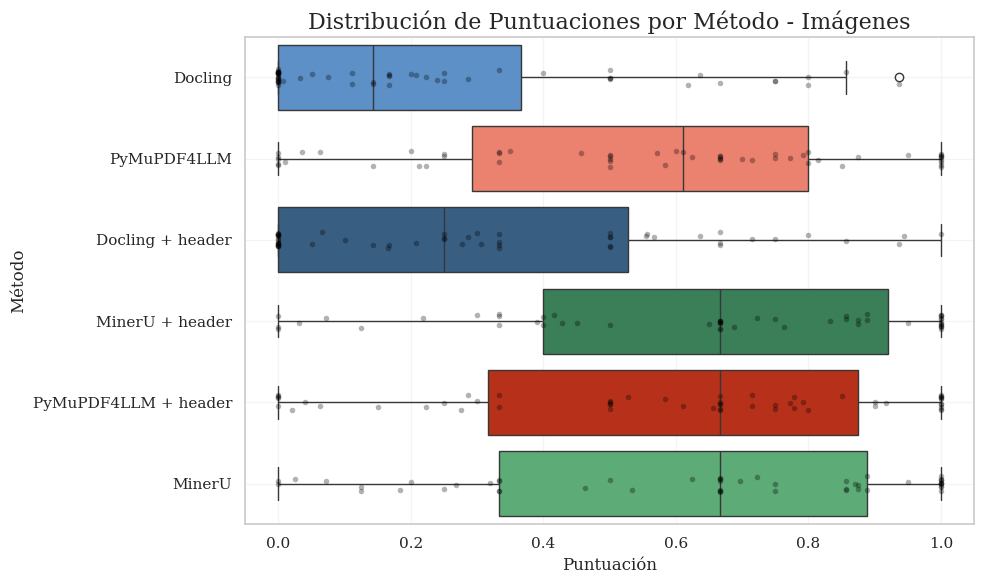

In [4]:
if not df_images.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in df_images['Metodo'].unique()]
    
    sns.boxplot(data=df_images, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    sns.stripplot(data=df_images, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
    
    plt.grid(axis='both', alpha=0.2)
    
    plt.title('Distribución de Puntuaciones por Método - Imágenes', fontsize=16)
    plt.xlabel('Puntuación', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de imágenes para visualizar.")

### 4. PDFs (Texto Seleccionable) - Puntuación Media por Método

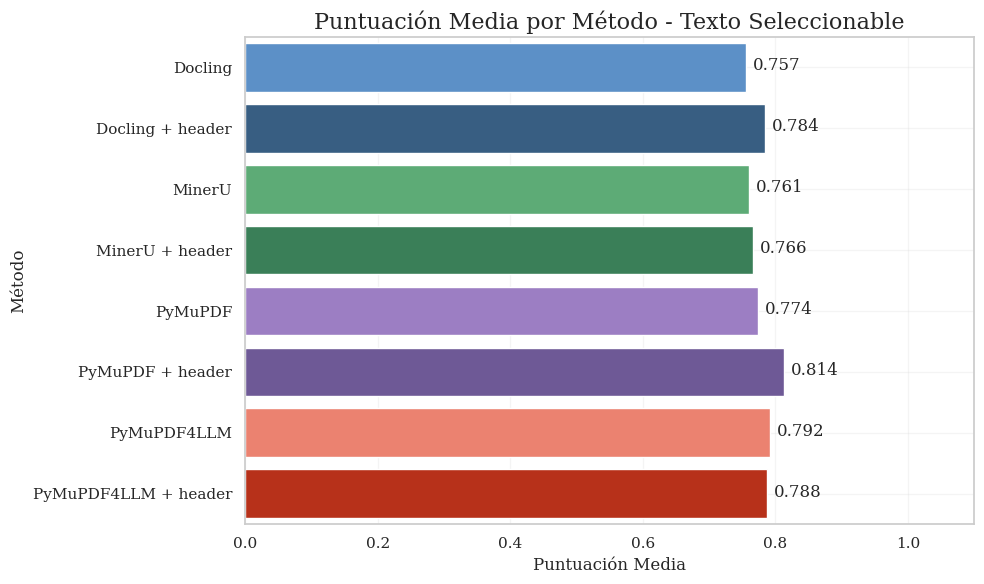

In [5]:
if not df_pdfs.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in mean_scores_pdfs['Metodo'].unique()]
    
    ax = sns.barplot(data=mean_scores_pdfs, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    plt.title('Puntuación Media por Método - Texto Seleccionable', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de PDFs para visualizar.")

### 5. PDFs (Texto Seleccionable) - Distribución de Puntuaciones (Boxplot)
Muestra la dispersión: si las cajas son pequeñas significa que el modelo es muy consistente. Si hay muchos puntos fuera (outliers) o las cajas son largas, significa que a veces saca 1 y otras 0.

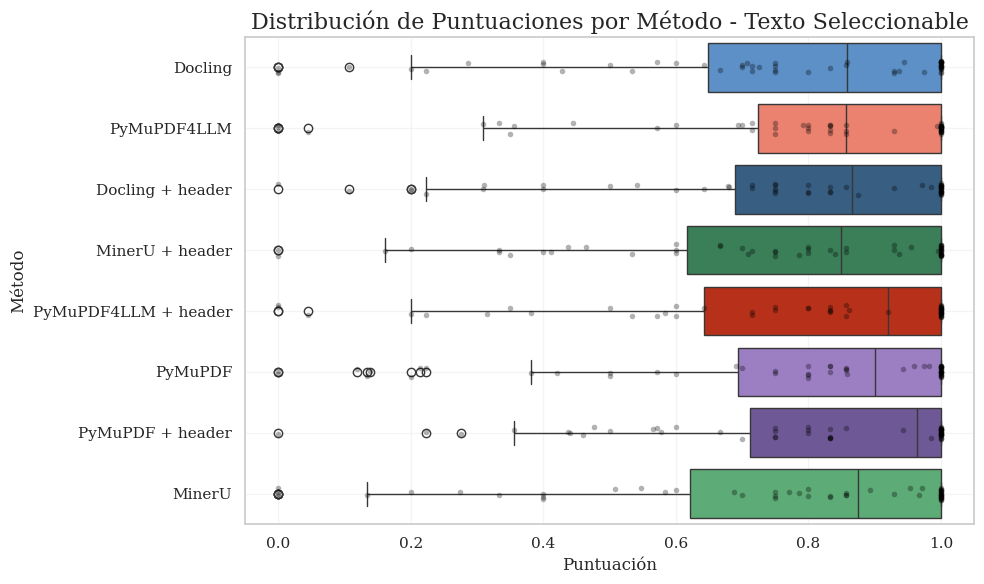

In [6]:
if not df_pdfs.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in df_pdfs['Metodo'].unique()]
    
    sns.boxplot(data=df_pdfs, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    sns.stripplot(data=df_pdfs, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
    
    plt.grid(axis='both', alpha=0.2)
    
    plt.title('Distribución de Puntuaciones por Método - Texto Seleccionable', fontsize=16)
    plt.xlabel('Puntuación', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de PDFs para visualizar.")

## Heatmap

In [7]:
import pandas as pd
from pathlib import Path

def load_evaluation_data(base_directory="final_evaluations"):
    # Initialize the base directory path
    evaluation_directory = Path(base_directory)
    data_frames_list = []
    
    # Iterate through the expected document types
    for document_type in ["images", "pdfs"]:
        type_directory = evaluation_directory / document_type
        if not type_directory.exists(): 
            continue
            
        # Iterate through each method directory
        for method_directory in type_directory.iterdir():
            if method_directory.is_dir():
                csv_file_path = method_directory / "results.csv"
                
                # Check if the CSV file exists and read it
                if csv_file_path.exists():
                    current_dataframe = pd.read_csv(csv_file_path)
                    current_dataframe['Metodo'] = method_directory.name
                    current_dataframe['Tipo Documento'] = document_type
                    data_frames_list.append(current_dataframe)
                    
    # Return an empty DataFrame if no data was found
    if not data_frames_list:
        return pd.DataFrame()
        
    compiled_dataframe = pd.concat(data_frames_list, ignore_index=True)
    
    # Convert the scoring column to numeric types to avoid aggregation errors
    # 'coerce' will turn non-numeric values (like "Error") into NaN
    compiled_dataframe['Puntuación'] = pd.to_numeric(compiled_dataframe['Puntuación'], errors='coerce')
    compiled_dataframe = compiled_dataframe.dropna(subset=['Puntuación'])
    
    return compiled_dataframe

df_plot = load_evaluation_data()

In [9]:
import pandas as pd
import plotly.graph_objects as go

def plot_spider_comparison(df, methods):
    # Group data and calculate mean and standard deviation
    stats = df.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].agg(['mean', 'std']).unstack()
    
    categories = ['Media (Img)', 'Consistencia (Img)', 'Media (PDF)', 'Consistencia (PDF)']
    
    fig = go.Figure()
    
    for method in methods:
        if method not in stats.index:
            continue
            
        # Helper function to safely extract values and handle missing data (NaNs)
        def safe_extract(metric, doc_type, invert_for_consistency=False):
            try:
                # Check if the column multi-index exists in the unstacked dataframe
                if (metric, doc_type) not in stats.columns:
                    return 0.0
                
                val = stats.loc[method, (metric, doc_type)]
                
                if pd.isna(val):
                    return 0.0
                    
                return 1.0 - val if invert_for_consistency else val
            except KeyError:
                return 0.0

        # Extract values, replacing missing or non-computable ones with 0.0
        values = [
            safe_extract('mean', 'images'),
            safe_extract('std', 'images', invert_for_consistency=True),
            safe_extract('mean', 'pdfs'),
            safe_extract('std', 'pdfs', invert_for_consistency=True)
        ]
        
        # Close the radar chart shape to complete the polygon
        values.append(values[0])
        temp_categories = categories + [categories[0]]
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=temp_categories,
            fill='toself',
            name=method
        ))
        
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=True,
        title="Comparativa Multidimensional de Métodos"
    )
    fig.show()

# Execution example
# plot_spider_comparison(df_plot, metodos_top)